# AI-ML Assignment 1

# Medical Insurance Cost Prediction using Multiple Linear Regression

**Name:** Abhishek Thakur

**Application Number :** IN26011189

**Assignment:** Assignment 1

**Batch :** 1A

**Objective:**

The objective of this assignment is to develop a Multiple Linear Regression model that predicts medical insurance charges based on customer information such as age, sex, BMI, number of children, smoking status, and region.

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Task 1: Data Understanding

In this section, the dataset is loaded and explored to understand its structure. The first five records are displayed, and the numerical features, categorical features, and target variable are identified.

In [2]:
# Load the dataset
df = pd.read_csv("dataset/insurance.csv")

print("Dataset Loaded Successfully!\n")

print("First Five Records:")
display(df.head())

print("\nDataset Shape:", df.shape)

print("\nDataset Information")
df.info()

print("\nStatistical Summary")
print(df.describe())

Dataset Loaded Successfully!

First Five Records:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Dataset Shape: (1338, 7)

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB

Statistical Summary
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.00

### Identifying Feature Types

The dataset contains numerical and categorical features. The target variable is also identified for the prediction task.

In [3]:
# Identify numerical features (excluding the target variable)
numerical_features = df.select_dtypes(include=["number"]).columns.tolist()
numerical_features.remove("charges")

# Identify categorical features
categorical_features = df.select_dtypes(include=["object", "string"]).columns.tolist()

# Target variable
target_variable = "charges"

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nTarget Variable:")
print(target_variable)

Numerical Features:
['age', 'bmi', 'children']

Categorical Features:
['sex', 'smoker', 'region']

Target Variable:
charges


# Task 2: Data Preprocessing

Data preprocessing prepares the dataset for machine learning by checking for missing values, encoding categorical variables into numerical form, and splitting the dataset into training and testing sets.

The categorical features (`sex`, `smoker`, and `region`) are encoded because the Multiple Linear Regression model requires numerical input.

In [4]:
# ==========================================
# Check for Missing Values
# ==========================================

print("Missing Values in Each Column:\n")
print(df.isnull().sum())

Missing Values in Each Column:

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


### Encoding Categorical Variables

Machine learning models cannot process categorical (text) values directly. Therefore, the categorical columns (`sex`, `smoker`, and `region`) are converted into numerical values using **Label Encoding**.

In [5]:
# ==========================================
# Encode Categorical Variables
# ==========================================

label_encoder = LabelEncoder()

df["sex"] = label_encoder.fit_transform(df["sex"])
df["smoker"] = label_encoder.fit_transform(df["smoker"])
df["region"] = label_encoder.fit_transform(df["region"])

print("Categorical variables encoded successfully!\n")

display(df.head())

Categorical variables encoded successfully!



,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


### Split the Dataset

The dataset is divided into training and testing sets.

- **80%** of the data is used for training the model.
- **20%** of the data is reserved for testing the model's performance.

The `random_state=42` parameter ensures reproducible results.

In [6]:
# ==========================================
# Split Features and Target Variable
# ==========================================

X = df.drop("charges", axis=1)
y = df["charges"]

# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print("\nTraining Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)

Training Features Shape : (1070, 6)
Testing Features Shape  : (268, 6)

Training Target Shape   : (1070,)
Testing Target Shape    : (268,)


### Observation

- The dataset contains no missing values, so no data cleaning was required.
- All categorical features were successfully converted into numerical values using Label Encoding.
- The dataset was split into training (80%) and testing (20%) sets, making it ready for model development.

# Task 3: Model Development

In this task, a **Multiple Linear Regression** model is developed to predict medical insurance charges. The model is trained using the training dataset and then used to predict insurance charges for the testing dataset.

Multiple Linear Regression is suitable because the target variable (**charges**) is continuous and depends on multiple independent features.

In [7]:
# ==========================================
# Build and Train the Multiple Linear Regression Model
# ==========================================

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Multiple Linear Regression model trained successfully!")

Multiple Linear Regression model trained successfully!


### Model Prediction

After training, the model is used to predict medical insurance charges for the testing dataset.

In [8]:
# ==========================================
# Predict Insurance Charges
# ==========================================

y_pred = model.predict(X_test)

print("First 10 Predicted Charges:\n")
print(y_pred[:10])

First 10 Predicted Charges:

[ 8924.40724442  7116.29501758 36909.01352144  9507.87469118
 27013.3500079  10790.77956153   226.29844571 16942.71599941
  1056.63079407 11267.91997309]


In [9]:
# Compare Actual vs Predicted Values

comparison = pd.DataFrame({
    "Actual Charges": y_test.values,
    "Predicted Charges": y_pred
})

comparison.head(10)

,Actual Charges,Predicted Charges
0,9095.06825,8924.407244
1,5272.17580,7116.295018
2,29330.98315,36909.013521
3,9301.89355,9507.874691
4,33750.29180,27013.350008
5,4536.25900,10790.779562
6,2117.33885,226.298446
7,14210.53595,16942.715999
8,3732.62510,1056.630794
9,10264.44210,11267.919973


### Observation

The Multiple Linear Regression model was successfully trained using the training dataset. Predictions were generated for the testing dataset and will be evaluated in the next task using regression evaluation metrics.

# Task 4: Model Evaluation

The performance of the Multiple Linear Regression model is evaluated using three commonly used regression metrics:

- **Mean Absolute Error (MAE)**
- **Mean Squared Error (MSE)**
- **R² Score**

Additionally, a scatter plot is created to compare the actual and predicted insurance charges.

In [10]:
# ==========================================
# Model Evaluation
# ==========================================

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("-" * 30)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation Metrics
------------------------------
Mean Absolute Error (MAE): 4186.51
Mean Squared Error (MSE): 33635210.43
R² Score: 0.7833


### Actual vs Predicted Scatter Plot

The following scatter plot compares the actual insurance charges with the values predicted by the Multiple Linear Regression model. A perfect model would place all points on the red diagonal line.

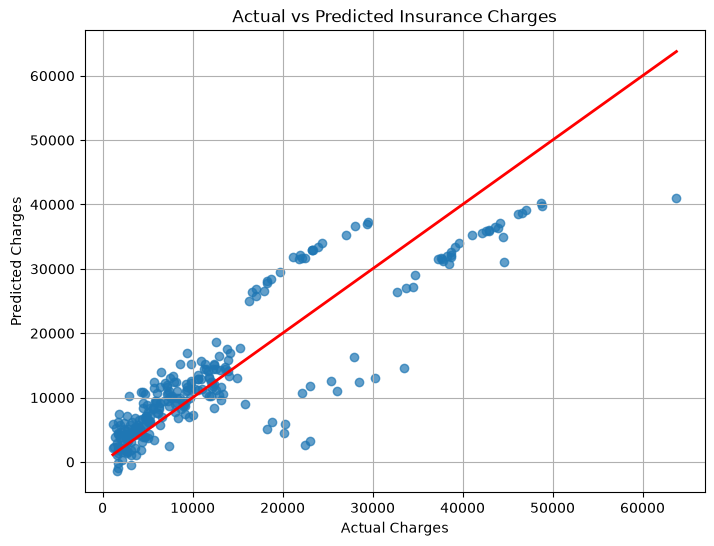

In [11]:
# ==========================================
# Actual vs Predicted Scatter Plot
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.title("Actual vs Predicted Insurance Charges")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.grid(True)

# Save the figure
plt.savefig("images/actual_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- The R² score indicates how well the model explains the variation in insurance charges.
- Lower MAE and MSE values indicate better prediction accuracy.
- Most data points are located close to the diagonal reference line, showing that the model provides reasonably accurate predictions, although some prediction errors are present.

# Task 5: Conclusion

This project successfully developed a **Multiple Linear Regression** model to predict medical insurance charges using features such as age, sex, BMI, number of children, smoking status, and region. The dataset was preprocessed by checking for missing values, encoding categorical variables, and splitting the data into training and testing sets. The trained model achieved an **R² Score of 0.7833**, indicating that it explains approximately **78.33%** of the variation in insurance charges. The evaluation metrics (MAE and MSE) suggest that the model provides reasonably accurate predictions for this dataset. Among the input features, smoking status, BMI, and age have a significant impact on insurance costs. A limitation of Multiple Linear Regression is its assumption of a linear relationship between features and the target variable, which may not capture more complex real-world patterns.